# Data Analysis & Visualization Tasks – Website Traffic & Conversion Data

## ✅ Analysis & Visualization Tasks:

### 1. Import Modules 📔📚

In [1]:
!python -m pip install -r requirements.txt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Defaulting to user installation because normal site-packages is not writeable


### 2. Load Dataset 📁

In [2]:
df = pd.read_csv("WebTraffic_Q1_2025.csv")
df.head()

,VisitDate,SessionDuration,PageViews,ReferralSource,DeviceType,Platform,BounceRate,Conversions
0,2025-03-17,140.78,3.0,Referral,Tablet,Windows,88.24,1
1,2025-01-03,903.04,3.0,Paid Search,Tablet,Windows,48.78,0
2,2025-02-25,395.02,5.0,Social Media,Mobile,macOS,51.13,0
3,2025-01-29,273.88,6.0,Referral,Desktop,macOS,60.36,0
4,2025-03-23,50.89,5.0,Organic Search,Mobile,Linux,88.83,1


### 3. Data Preparation & Data Cleaning 😎🧹

In [3]:
df["VisitDate"] = pd.to_datetime(df["VisitDate"])
df["VisitMonth"] = df["VisitDate"].dt.month_name()
df["VisitDayOfWeek"] = df["VisitDate"].dt.day_name()
df["VisitWeekNumber"] = df["VisitDate"].dt.isocalendar().week


In [4]:
df.isna().sum()

VisitDate           0
SessionDuration    12
PageViews           9
ReferralSource      0
DeviceType          0
Platform            0
BounceRate          0
Conversions         0
VisitMonth          0
VisitDayOfWeek      0
VisitWeekNumber     0
dtype: int64

In [5]:
df["SessionDuration"] = df["SessionDuration"].fillna(df["SessionDuration"].mean())
df["PageViews"] = df["PageViews"].fillna(df["PageViews"].median())

df.isna().sum()

VisitDate          0
SessionDuration    0
PageViews          0
ReferralSource     0
DeviceType         0
Platform           0
BounceRate         0
Conversions        0
VisitMonth         0
VisitDayOfWeek     0
VisitWeekNumber    0
dtype: int64

In [6]:
if df.duplicated().sum() != 0:
    df = df.drop_duplicates()
    print("Duplicate rows found and removed!")
else:
    print("No duplicate rows found!")

No duplicate rows found!


### 4. Traffic Trend Analysis 🚦📈

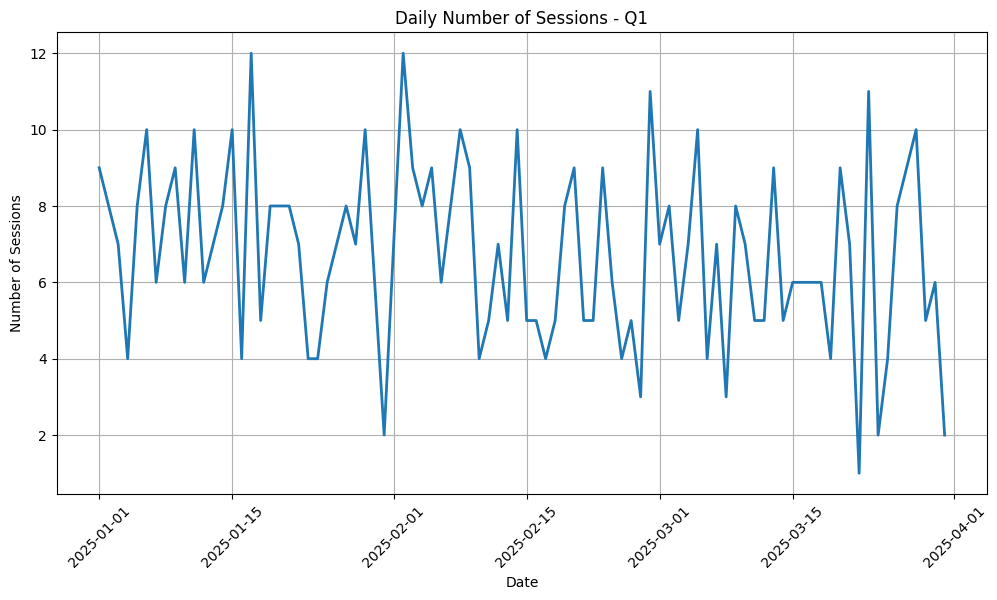

In [7]:
# ○ Plot the daily number of sessions over time for Q1.
q1_data = df[df["VisitDate"].dt.quarter == 1]

daily_sessions = q1_data.groupby("VisitDate").size()

plt.figure(figsize=(12, 6))
plt.plot(daily_sessions.index, daily_sessions.values, linewidth=2)
plt.title("Daily Number of Sessions - Q1")
plt.xlabel("Date")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.grid()
plt.show()

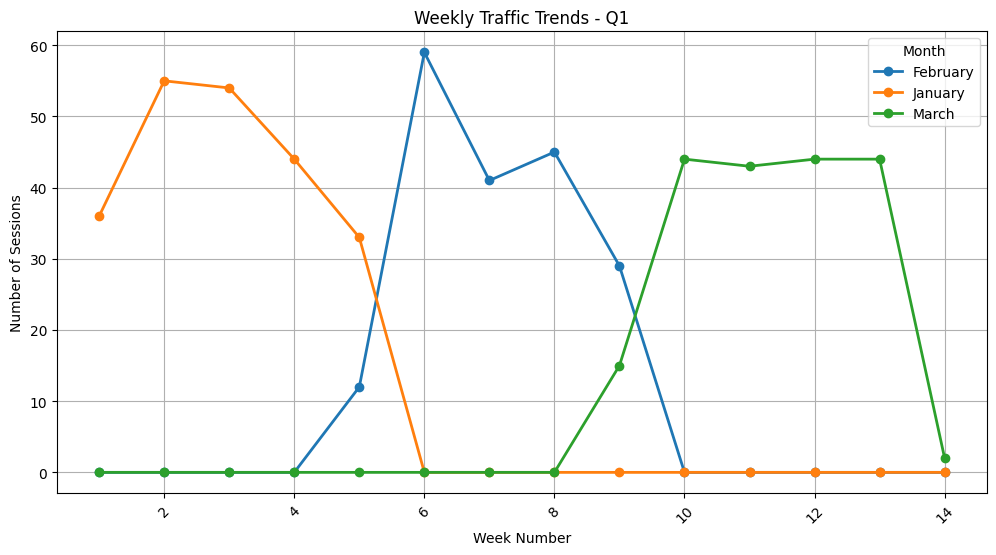

In [8]:
# ○ Generate a line chart comparing weekly traffic trendsacross January, February, and March.
weekly_sessions = q1_data.groupby(["VisitWeekNumber", "VisitMonth"]).size().unstack(fill_value=0)
# Plot
plt.figure(figsize=(12, 6))
for month in weekly_sessions.columns:
    plt.plot(weekly_sessions.index, weekly_sessions[month], marker='o', label=month, linewidth=2)
plt.title("Weekly Traffic Trends - Q1")
plt.xlabel("Week Number")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.legend(title="Month")
plt.grid()
plt.show()

### 5. User Engagement Metrics 👤📈📊

In [9]:
# ○ Calculate the average session duration and average page views per session. 
average_session_duration = df["SessionDuration"].mean()
average_page_views = df["PageViews"].mean()

print(f"Average Session Duration: {average_session_duration:.2f} seconds")
print(f"Average Page Views per Session: {average_page_views:.2f}")

Average Session Duration: 310.73 seconds
Average Page Views per Session: 4.95


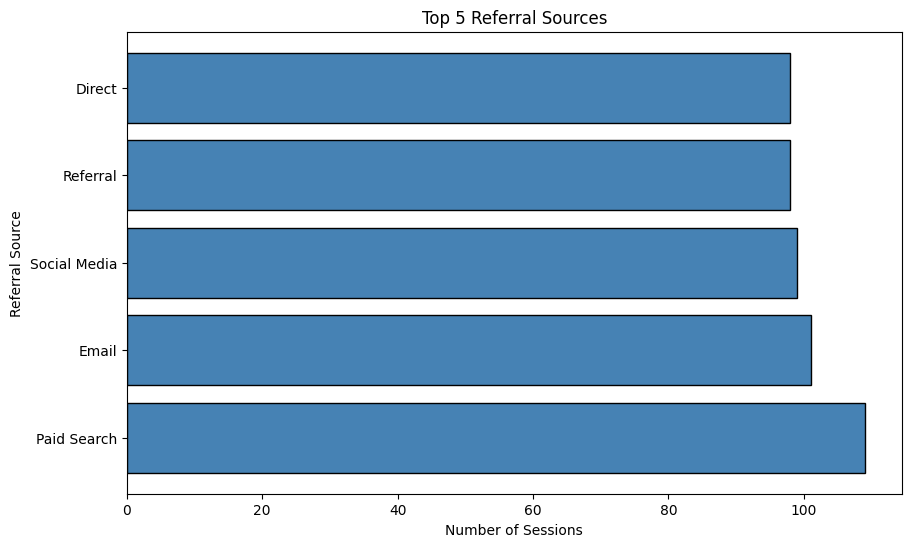

In [10]:
# ○ Identify the top 5 referral sources bringing the most traffic and visualize this with a horizontal bar chart.
top_referrals = df["ReferralSource"].value_counts().head(5)

plt.figure(figsize=(10, 6))
plt.barh(top_referrals.index, top_referrals.values, color='steelblue', edgecolor='black')
plt.title("Top 5 Referral Sources")
plt.xlabel("Number of Sessions")
plt.ylabel("Referral Source")
plt.show()

### 6. Conversion Analysis 🎯📈

In [11]:
# ○ Calculate the overall conversion rate (Total conversions / Total sessions).
conversion_rate = df["Conversions"].mean() * 100

print(f"Overall Conversion Rate: {conversion_rate:.2f}%")


Overall Conversion Rate: 14.33%


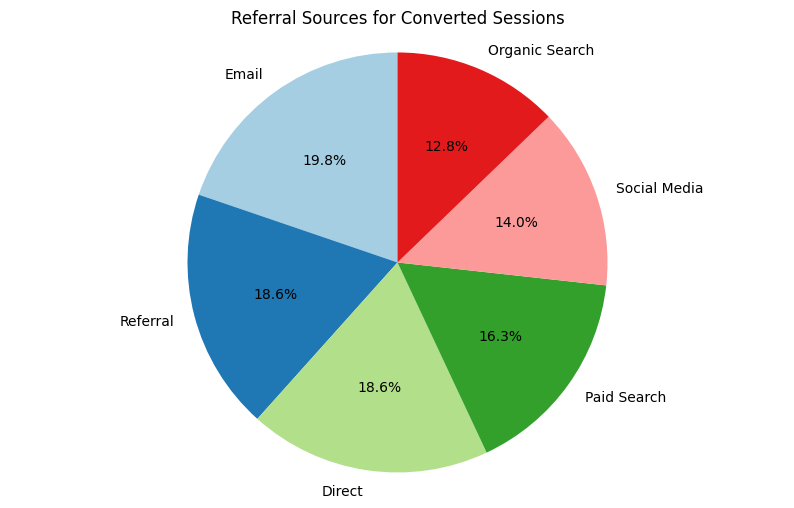

In [12]:
# ○ Identify the top 5 referral sources bringing the most traffic and visualize this with a horizontal bar chart.
top_referrals = df[df["Conversions"] == 1]["ReferralSource"].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(top_referrals.values, labels=top_referrals.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
plt.title("Referral Sources for Converted Sessions")
plt.axis('equal')
plt.show()

### 7. Device & Platform Insights 🖥️💠

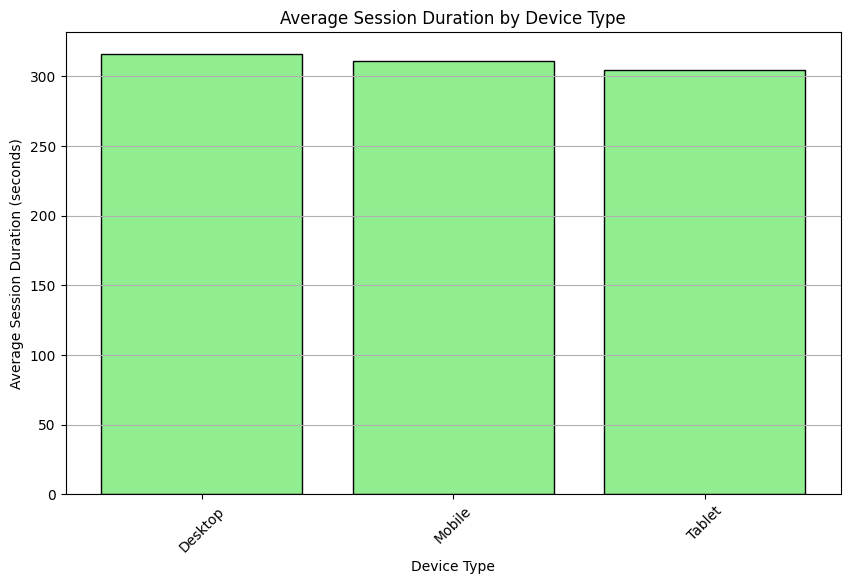

In [13]:
# ○ Group data by device type (Desktop, Mobile, Tablet) and show average session duration for each.
device_group = df.groupby("DeviceType")["SessionDuration"].mean()

plt.figure(figsize=(10, 6))
plt.bar(device_group.index, device_group.values, color='lightgreen', edgecolor='black')
plt.title("Average Session Duration by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Session Duration (seconds)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

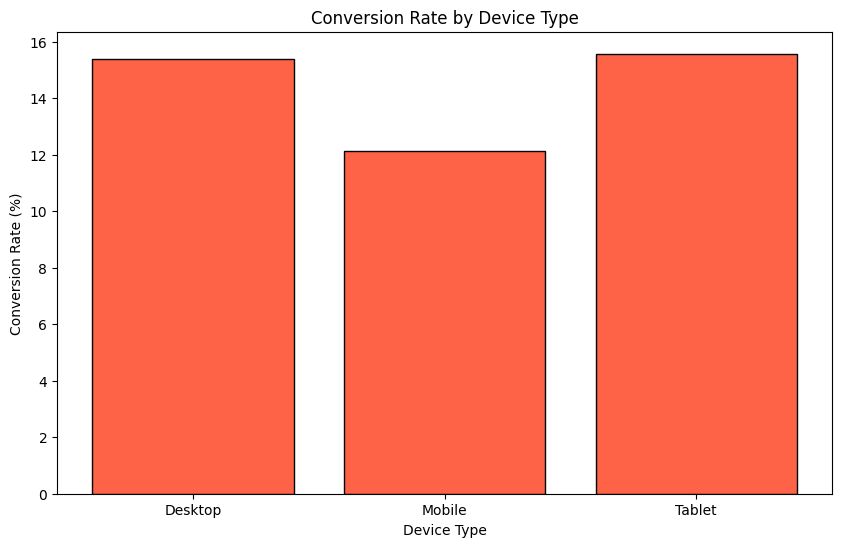

In [14]:
# ○ Plot a grouped bar chart of conversion rate by device type.
conversion_by_device = df.groupby("DeviceType")["Conversions"].mean()
plt.figure(figsize=(10, 6))
plt.bar(conversion_by_device.index, conversion_by_device.values * 100, color='tomato', edgecolor='black')
plt.title("Conversion Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Conversion Rate (%)")
plt.show()

### 8. Bounce Rate Pattern ⛹🏻‍♂️🏷️🔗

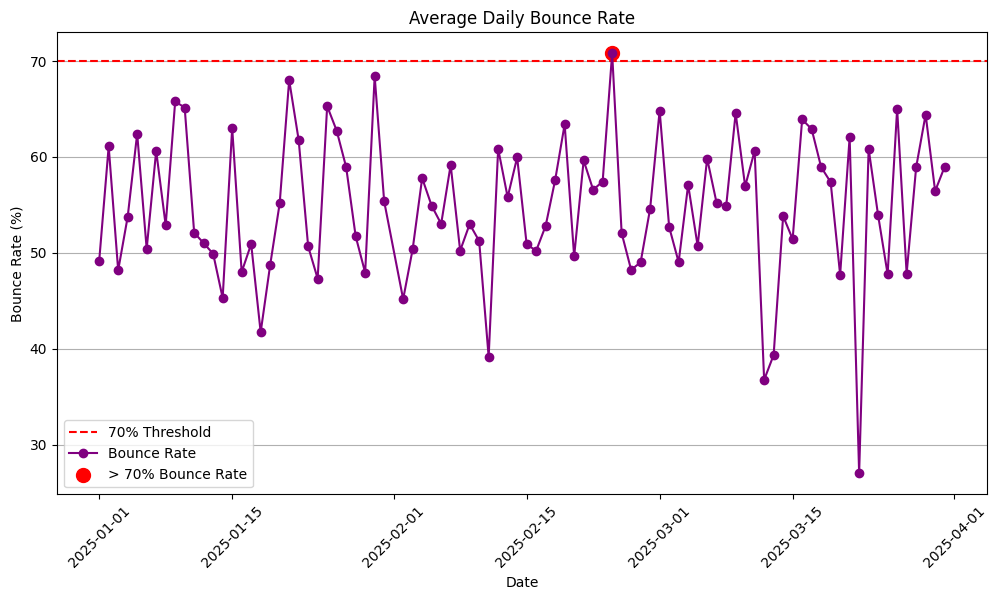

In [15]:
# ○ Plot a line graph of average daily bounce rate.
# ○ Highlight days where the bounce rate exceeded 70%. 
daily_bounce_rate = df.groupby("VisitDate")["BounceRate"].mean()

high_bounce_days = daily_bounce_rate[daily_bounce_rate > 70]

plt.figure(figsize=(12, 6))
plt.axhline(y=70, color='r', linestyle='--', label='70% Threshold')
plt.plot(daily_bounce_rate.index, daily_bounce_rate.values, marker='o', linestyle='-', color='purple', label='Bounce Rate')
plt.scatter(high_bounce_days.index, high_bounce_days.values, color='red', s=100, label='> 70% Bounce Rate')
plt.title("Average Daily Bounce Rate")
plt.xlabel("Date")
plt.ylabel("Bounce Rate (%)")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend()
plt.show()